This is a file created to generate some figures for my master’s thesis.
M365 Copilot generated the base code and then I modified it.

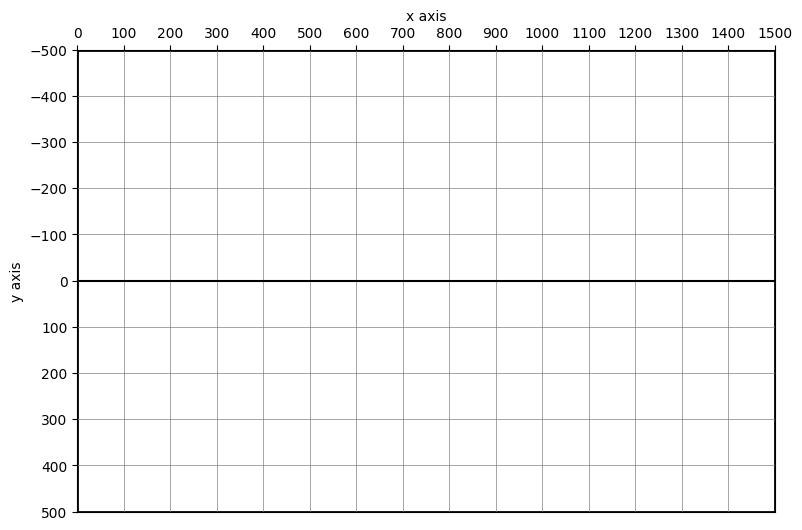

In [1]:
# Figure 3.1
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(figsize=(9,6))

ax.set_xlim(0, 1500)
ax.set_ylim(-500, 500)

ax.set_xticks(np.arange(0, 1501, 100))
ax.set_yticks(np.arange(-500, 501, 100))
ax.grid(True, color='gray', linewidth=0.5)

rect = patches.Rectangle(
    (0, -500),
    1500,
    1000,
    linewidth=2,
    edgecolor='black',
    facecolor='none'
)
ax.add_patch(rect)

ax.axhline(0, color='black', linewidth=1.5)  # 太いx軸
ax.spines['top'].set_color('black')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.invert_yaxis()

ax.set_xlabel('x axis')
ax.set_ylabel('y axis')

plt.savefig('coordinate-plane.jpg')
plt.show()

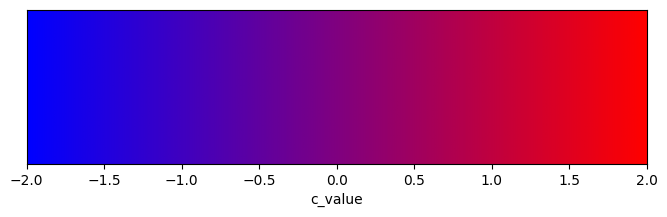

In [2]:
# Figure 3.2

from matplotlib.colors import LinearSegmentedColormap

c_values = np.linspace(-2, 2, 600)
gradient = np.tile(c_values, (50, 1))

cmap = LinearSegmentedColormap.from_list(
    'custom',
    ['blue', 'red']
)

fig, ax = plt.subplots(figsize=(8, 2))

im = ax.imshow(
    gradient,
    aspect='auto',
    cmap=cmap,
    extent=[-2, 2, 0, 1]
)

ax.set_yticks([])

ax.set_xlabel('c_value')

plt.savefig('c-net.jpg')
plt.show()

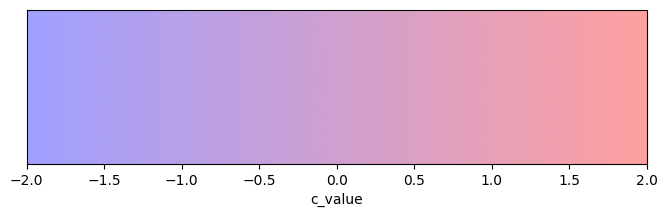

In [3]:
# Figure 3.3

c_values = np.linspace(-2, 2, 600)
gradient = np.tile(c_values, (50, 1))

cmap = LinearSegmentedColormap.from_list(
    'custom',
    ['#A0A0FF', '#FFA0A0']
)

fig, ax = plt.subplots(figsize=(8, 2))

im = ax.imshow(
    gradient,
    aspect='auto',
    cmap=cmap,
    extent=[-2, 2, 0, 1]
)

ax.set_yticks([])

ax.set_xlabel('c_value')

plt.savefig('c-list.jpg')
plt.show()

In [ ]:
# Fig 5.1

import pandas as pd

file_path = 'survey-multi.csv'
df = pd.read_csv(file_path)

df.head()

,Q1,Q2,Q3,Q4,Q5,Q6
0,3,4,2,5,5,2
1,3,4,4,3,5,4
2,5,4,5,4,5,5
3,4,4,5,4,5,5
4,4,5,4,5,5,5


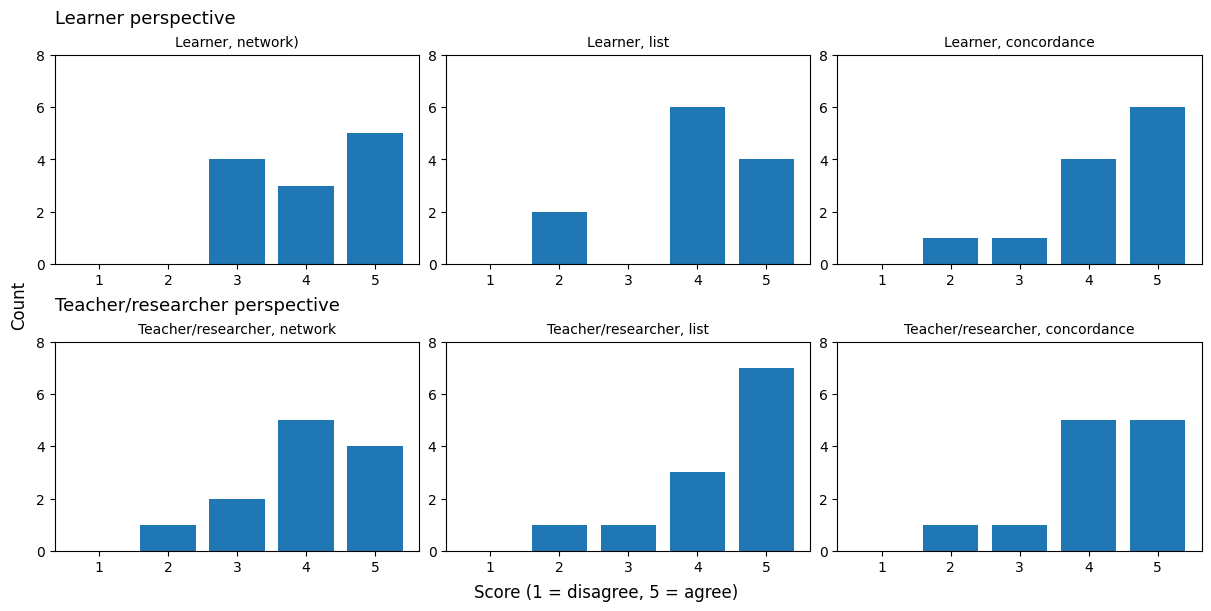

In [6]:
titles = [
    "Learner, network)",
    "Learner, list",
    "Learner, concordance",
    "Teacher/researcher, network",
    "Teacher/researcher, list",
    "Teacher/researcher, concordance"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)

for i, col in enumerate(df.columns):

    ax = axes[i // 3, i % 3]

    counts = df[col].value_counts().sort_index()
    counts = counts.reindex([1,2,3,4,5], fill_value=0)

    ax.bar(counts.index, counts.values)
    ax.set_title(titles[i], fontsize=10)
    ax.set_xticks([1,2,3,4,5])
    ax.set_ylim(0, 8)

fig.supxlabel("Score (1 = disagree, 5 = agree)")
fig.supylabel("Count")

axes[0, 0].annotate("Learner perspective",
                    xy=(0, 1.15),
                    xycoords="axes fraction",
                    fontsize=13,
                    ha="left")

axes[1, 0].annotate("Teacher/researcher perspective",
                    xy=(0, 1.15),
                    xycoords="axes fraction",
                    fontsize=13,
                    ha="left")

plt.savefig('survey-results.jpg')
plt.show()
